# XGBoost Model

## Humaid Billoo



### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

### Data Setup

In [2]:
df = pd.read_excel('data/Working Version - default of credit card clients.xls', header=1)
df = pd.DataFrame(df)
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT5,PAY_AMT6,default payment next month,UTIL_t1,UTIL_t2,UTIL_t3,UTIL_t4,UTIL_t5,UTIL_t6,Average of Util Over 6 Months
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,1,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200
1,2,120000,2,2,2,26,-1,2,0,0,...,0,2000,1,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718
2,3,90000,2,2,2,34,0,0,0,0,...,1000,5000,0,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246
3,4,50000,2,2,1,37,0,0,0,0,...,1069,1000,0,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113
4,5,50000,1,2,1,57,-1,0,-1,0,...,689,679,0,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463
5,6,50000,1,1,2,37,0,0,0,0,...,1000,800,0,1.288000,1.141380,1.152160,0.387880,0.392380,0.400480,0.793713
6,7,500000,1,1,2,29,0,0,0,0,...,13750,13770,0,0.735930,0.824046,0.890014,1.085306,0.966006,0.947888,0.908198
7,8,100000,2,2,2,23,0,-1,-1,0,...,1687,1542,0,0.118760,0.003800,0.006010,0.002210,-0.001590,0.005670,0.022477
8,9,140000,2,3,1,28,0,0,2,0,...,1000,1000,0,0.080607,0.100686,0.086486,0.087221,0.084236,0.026564,0.077633
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,1122,0,0,0.000000,0.000000,0.000000,0.000000,0.650350,0.695600,0.224325


### Define X Y

In [3]:
X = df.drop(columns=['ID', 'default payment next month'])
y = df['default payment next month']

### Cat Var ecoding

In [4]:
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("Encoded X shape:", X.shape)

Encoded X shape: (30000, 98)


### Data Split 70/20/10

In [5]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, 
    y,
    test_size=0.10,
    stratify=y,
    random_state=99)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, 
    y_trainval,
    test_size=0.2222,
    stratify=y_trainval,
    random_state=99)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (21000, 98)
Val shape: (6000, 98)
Test shape: (3000, 98)


### Class Imbalance

In [6]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", round(scale_pos_weight, 3))


scale_pos_weight: 3.521


### Base Model

In [7]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=99,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

### Hyperparameter

In [8]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=28)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=99,
    n_jobs=-1
)

### Best fit

In [9]:
search.fit(X_train, y_train)

print("\nBest Params:")
print(search.best_params_)
print("Best CV AUC:", round(search.best_score_, 4))

best_model = search.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Params:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best CV AUC: 0.7851


### Validation pred

In [10]:
y_val_prob = best_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.50).astype(int)

print("\nVALIDATION RESULTS")
print("Accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("AUC:", round(roc_auc_score(y_val, y_val_prob), 4))
print("F1:", round(f1_score(y_val, y_val_pred), 4))
print("Precision:", round(precision_score(y_val, y_val_pred), 4))
print("Recall:", round(recall_score(y_val, y_val_pred), 4))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("\nClassification Report - Validation")
print(classification_report(y_val, y_val_pred, digits=4))



VALIDATION RESULTS
Accuracy: 0.765
AUC: 0.7846
F1: 0.5437
Precision: 0.4765
Recall: 0.633
Confusion Matrix:
 [[3750  923]
 [ 487  840]]

Classification Report - Validation
              precision    recall  f1-score   support

           0     0.8851    0.8025    0.8418      4673
           1     0.4765    0.6330    0.5437      1327

    accuracy                         0.7650      6000
   macro avg     0.6808    0.7177    0.6927      6000
weighted avg     0.7947    0.7650    0.7758      6000



### Test prediction

In [11]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.50).astype(int)

print("\nTEST RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_test_prob), 4))
print("F1:", round(f1_score(y_test, y_test_pred), 4))
print("Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Recall:", round(recall_score(y_test, y_test_pred), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report - Test")
print(classification_report(y_test, y_test_pred, digits=4))


TEST RESULTS
Accuracy: 0.7557
AUC: 0.7947
F1: 0.5433
Precision: 0.4633
Recall: 0.6566
Confusion Matrix:
 [[1831  505]
 [ 228  436]]

Classification Report - Test
              precision    recall  f1-score   support

           0     0.8893    0.7838    0.8332      2336
           1     0.4633    0.6566    0.5433       664

    accuracy                         0.7557      3000
   macro avg     0.6763    0.7202    0.6883      3000
weighted avg     0.7950    0.7557    0.7691      3000



### threshold tuning on validation

In [12]:
thresholds = np.arange(0.10, 0.91, 0.01)

best_thresh = 0.50
best_f1 = 0

for t in thresholds:
    preds = (y_val_prob >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("\nBest validation threshold:", best_thresh)
print("Best validation F1:", best_f1)



Best validation threshold: 0.5099999999999998
Best validation F1: 0.5473128915265414


### Test eval Tuned

In [13]:
y_test_pred_opt = (y_test_prob >= best_thresh).astype(int)

print("\nTEST RESULTS WITH OPTIMAL THRESHOLD")
print("Accuracy:", round(accuracy_score(y_test, y_test_pred_opt), 4))
print("AUC:", round(roc_auc_score(y_test, y_test_prob), 4))
print("F1:", round(f1_score(y_test, y_test_pred_opt), 4))
print("Precision:", round(precision_score(y_test, y_test_pred_opt), 4))
print("Recall:", round(recall_score(y_test, y_test_pred_opt), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_opt))
print("\nClassification Report - Test (Optimal Threshold)")
print(classification_report(y_test, y_test_pred_opt, digits=4))


TEST RESULTS WITH OPTIMAL THRESHOLD
Accuracy: 0.763
AUC: 0.7947
F1: 0.5463
Precision: 0.474
Recall: 0.6446
Confusion Matrix:
 [[1861  475]
 [ 236  428]]

Classification Report - Test (Optimal Threshold)
              precision    recall  f1-score   support

           0     0.8875    0.7967    0.8396      2336
           1     0.4740    0.6446    0.5463       664

    accuracy                         0.7630      3000
   macro avg     0.6807    0.7206    0.6929      3000
weighted avg     0.7959    0.7630    0.7747      3000



### Feature Importance


Top 20 Features:
                          Feature  Importance
38                        PAY_0_2    0.198283
49                        PAY_2_2    0.173820
60                        PAY_3_2    0.070575
71                        PAY_4_2    0.046945
81                        PAY_5_2    0.024798
91                        PAY_6_2    0.024352
8                        PAY_AMT1    0.023910
37                        PAY_0_1    0.021904
36                        PAY_0_0    0.019753
50                        PAY_2_3    0.018386
47                        PAY_2_0    0.017737
9                        PAY_AMT2    0.016137
10                       PAY_AMT3    0.014291
0                       LIMIT_BAL    0.014078
34                       PAY_0_-2    0.013616
15                        UTIL_t2    0.013071
20  Average of Util Over 6 Months    0.011932
39                        PAY_0_3    0.009768
11                       PAY_AMT4    0.009753
13                       PAY_AMT6    0.009314


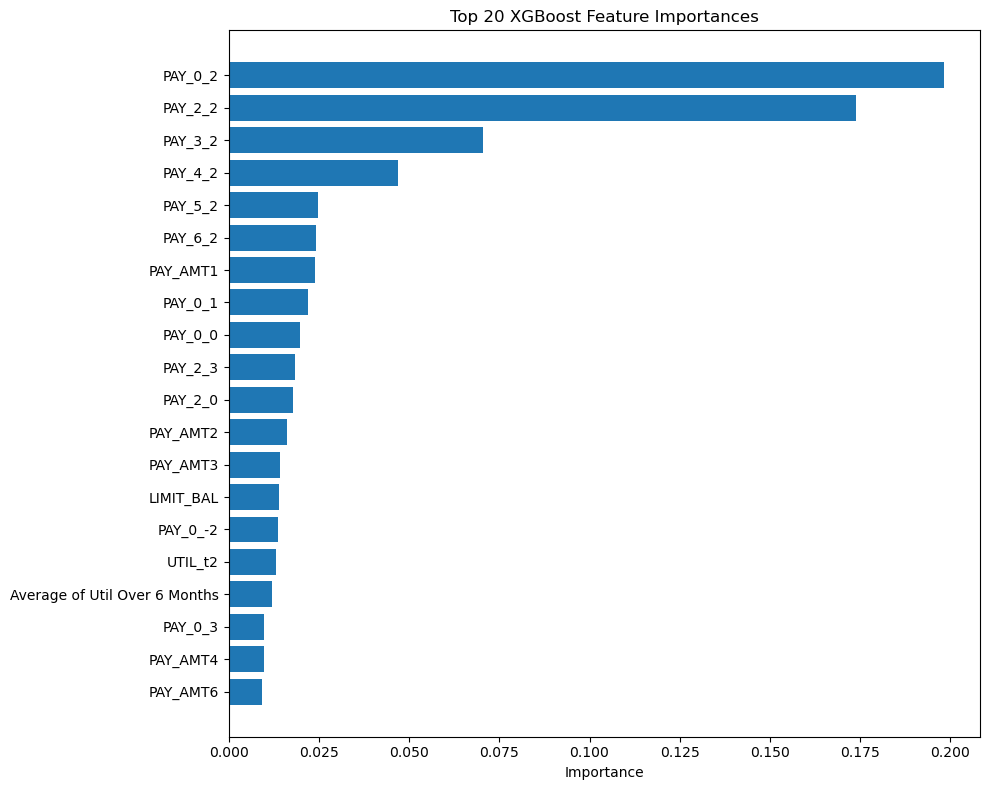

In [14]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 20 Features:")
print(importance_df.head(20))

top20 = importance_df.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20["Feature"], top20["Importance"])
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### The feature importance results show that repayment status variables are the most influential predictors of credit card default in the XGBoost model. Indicators such as PAY_0_2, PAY_2_2, PAY_3_2, and PAY_4_2 have the highest importance scores, suggesting that borrowers who are several months behind on payments are significantly more likely to default. This is consistent with financial intuition, since recent delinquency behavior is a strong signal of future credit risk. Several payment amount variables (PAY_AMT1, PAY_AMT2, PAY_AMT3) also appear among the top predictors, indicating that recent repayment activity contributes useful information to the model. Additionally, credit limit (LIMIT_BAL) and utilization related variables such as UTIL_t2 and the average utilization over six months appear within the top features, suggesting that how much credit a borrower uses relative to their limit also affects predicted default probability. Overall, the results indicate that while repayment history is the dominant driver of default prediction, credit utilization patterns and payment behavior still play an important role in the model.

# Results

In [15]:
print("SUMMARY OF RESULTS\n")

print(f"Best cross-validated AUC from randomized search: {search.best_score_:.4f}")
print(f"Best validation threshold based on F1: {best_thresh:.2f}\n")

print("Before threshold tuning (default threshold = 0.50):")
print(f"  Test AUC:       {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"  Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Test Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"  Test Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"  Test F1-score:  {f1_score(y_test, y_test_pred):.4f}\n")

print("After threshold tuning:")
print(f"  Test AUC:       {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"  Test Accuracy:  {accuracy_score(y_test, y_test_pred_opt):.4f}")
print(f"  Test Precision: {precision_score(y_test, y_test_pred_opt):.4f}")
print(f"  Test Recall:    {recall_score(y_test, y_test_pred_opt):.4f}")
print(f"  Test F1-score:  {f1_score(y_test, y_test_pred_opt):.4f}\n")

print("Context:")
print("The AUC shows how well the model ranks defaulters above non-defaulters.")
print("An AUC near 0.80 indicates strong performance for this dataset.")
print("Before tuning, the model already performed well using the default 0.50 threshold.")
print("After tuning, the threshold slightly improved F1-score and accuracy by giving a better balance between precision and recall.")
print("This suggests the model is reasonably effective at identifying default risk, while still reflecting the tradeoff between catching more defaulters and avoiding false positives.")

SUMMARY OF RESULTS

Best cross-validated AUC from randomized search: 0.7851
Best validation threshold based on F1: 0.51

Before threshold tuning (default threshold = 0.50):
  Test AUC:       0.7947
  Test Accuracy:  0.7557
  Test Precision: 0.4633
  Test Recall:    0.6566
  Test F1-score:  0.5433

After threshold tuning:
  Test AUC:       0.7947
  Test Accuracy:  0.7630
  Test Precision: 0.4740
  Test Recall:    0.6446
  Test F1-score:  0.5463

Context:
The AUC shows how well the model ranks defaulters above non-defaulters.
An AUC near 0.80 indicates strong performance for this dataset.
Before tuning, the model already performed well using the default 0.50 threshold.
After tuning, the threshold slightly improved F1-score and accuracy by giving a better balance between precision and recall.
This suggests the model is reasonably effective at identifying default risk, while still reflecting the tradeoff between catching more defaulters and avoiding false positives.
